# XGBoost Simulation d'Imputation en Test (Corrigé)

## Objectif
Évaluer la robustesse du modèle XGBoost en simulant un cas réel où seules la Matière Sèche (MS) et les Protéines (PB) sont connues.

**Méthodologie** :
1. **Entraînement** : Sur données réelles (`OOD == 0`).
2. **Simulation** : Sur l'ensemble de TEST, on remplace les variables labo par les moyennes de la `Feedtable` pour le même produit.
3. **Variables préservées** : `MS % brut` et `PB % brut` (considérées comme connues).

In [2]:
import sys
sys.path.insert(0, '../')
DATA_DIR = '../data/'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data import load_data_excel, convert_numeric_columns
from src.features import get_simplified_names
from src.experiments import prepare_data_random_split, train_xgboost_models
from src.visu import plot_ml_results

data_full = pd.read_excel(DATA_DIR + 'sources/data_merged_with_ood_classification.xlsx')
data = data_full[data_full['OOD'] == 0].copy()

vars_expl = [
    "MS % brut", "PB % brut", "CB % brut", "MGR % brut", "MM % brut",
    "NDF % brut", "ADF % brut", "Lignine % brut", "Amidon % brut", "Sucres % brut"
]
vars_cibles = [
    "EB (kcal) kcal/kg brut", "ED porc croissance (kcal) kcal/kg brut",
    "EM porc croissance (kcal) kcal/kg brut", "EN porc croissance (kcal) kcal/kg brut",
    "EMAn coq (kcal) kcal/kg brut", "EMAn poulet (kcal) kcal/kg brut",
    "UFL 2018 par kg brut", "UFV 2018 par kg brut", "PDIA 2018 g/kg brut",
    "PDI 2018 g/kg brut", "BalProRu 2018 g/kg brut"
]

data = convert_numeric_columns(data, vars_expl + vars_cibles)
simplified_names = get_simplified_names()

print(f"✓ Dataset prêt : {len(data)} lignes, {data['Nom'].nunique()} produits.")

✓ Dataset prêt : 6428 lignes, 139 produits.


In [3]:
print("\nENTRAÎNEMENT - BASELINE (Données réelles)")

metadata_cols = ['Nom', 'source']

X_train, X_test, y_train, y_test = prepare_data_random_split(
    data, 
    vars_expl + metadata_cols, 
    vars_cibles, 
    test_size=0.2, 
    random_state=42
)

results_baseline, metrics_baseline, models_baseline = train_xgboost_models(
    X_train[vars_expl], 
    X_test[vars_expl], 
    y_train, 
    y_test,
    vars_cibles, 
    simplified_names, 
    random_state=42
)

print(f" Modèles entraînés. R² moyen baseline: {metrics_baseline['R2_variance_weighted']:.4f}")


ENTRAÎNEMENT - BASELINE (Données réelles)
 Modèles entraînés. R² moyen baseline: 0.9913


In [4]:
# =================================================================
# VÉRIFICATION DU MAPPING : NOM ORIGINE VS NOM RÉFÉRENTIEL
# =================================================================

# On récupère les noms uniques présents dans le set de test (IA uniquement)
noms_test_ia = X_test[X_test['source'] == 'Donnees_IA']['Nom'].unique()

print(f"{'NOM ÉCHANTILLON (IA)':<40} | {'NOM RÉFÉRENCE (FEEDTABLE)':<40} | {'STATUT'}")
print("-" * 105)

mapping_verif = []

for nom in noms_test_ia:
    # On vérifie si le nom existe dans notre ref_table (l'index de ref_table est le Nom)
    if nom in ref_table.index:
        nom_ref = nom # Le match est exact
        statut = " MATCH EXACT"
    else:
        # Si pas de match exact, le fallback utilise la moyenne globale
        nom_ref = "MOYENNE GLOBALE (Fallback)"
        statut = " NON TROUVÉ"
    
    mapping_verif.append({
        'Origine': nom,
        'Référence': nom_ref,
        'Statut': statut
    })

# Affichage des 20 premiers pour vérification
for m in mapping_verif[:20]:
    print(f"{m['Origine']:<40} | {m['Référence']:<40} | {m['Statut']}")

print(f"\nRésumé : {sum(1 for x in mapping_verif if 'MATCH EXACT' in x['Statut'])} matchs réussis sur {len(noms_test_ia)} produits uniques.")

NOM ÉCHANTILLON (IA)                     | NOM RÉFÉRENCE (FEEDTABLE)                | STATUT
---------------------------------------------------------------------------------------------------------


NameError: name 'ref_table' is not defined

In [56]:
from thefuzz import process, fuzz

# --- ÉTAPE A : Préparer la liste des noms de référence ---
noms_feedtable = ref_table.index.tolist()
unique_ia_names = X_test.loc[X_test['source'] == 'Donnees_IA', 'Nom'].unique()

# --- ÉTAPE B : Créer le dictionnaire de mapping intelligent ---
smart_mapping = {}
print(" Recherche de correspondances par similarité...")

for nom in unique_ia_names:
    # On cherche le nom le plus proche avec un score
    best_match, score = process.extractOne(nom, noms_feedtable, scorer=fuzz.token_sort_ratio)
    
    # On accepte le match si le score est élevé (ex: > 70)
    if score >= 70:
        smart_mapping[nom] = best_match
        print(f" {nom[:30]:<30} -> {best_match[:30]} ({score}%)")
    else:
        smart_mapping[nom] = None
        print(f" {nom[:30]:<30} -> PAS DE MATCH ({score}%)")

 Recherche de correspondances par similarité...
 Farine de viande (toutes)      -> Farine de sang (70%)
 Radicelles d'orge de brasserie -> Radicelles d'orge de brasserie (100%)
 Tourteau de germes de maïs, hu -> Tourteau de germes de maïs, hu (100%)
 Tourteau de colza, huile < 5 % -> Tourteau de colza, huile < 5% (100%)
 Graine de coton                -> Graine de coton (100%)
 Farine basse de blé tendre     -> Farine basse de blé tendre (100%)
 Levure de brasserie déshydraté -> Levure de brasserie déshydraté (100%)
 Tourteau de coprah, huile 5-20 -> Tourteau de coprah, huile 5-20 (100%)
 Concentré protéique de luzerne -> Concentré protéique de luzerne (100%)
 Blé tendre                     -> Blé tendre (100%)
 Son de maïs                    -> Son de maïs (100%)
 Gluten feed de blé, type 20% a -> Gluten feed de blé, type 20% a (100%)
 Drêches de blé de distillerie, -> Drêches de blé de distillerie, (100%)
 Corn gluten feed               -> Corn gluten feed (100%)
 Paille de blé      

In [71]:
from thefuzz import process, fuzz

# 1. Configuration du seuil
SEUIL_CONFIANCE = 90
# 2. Préparation du mapping
noms_feedtable = ref_table.index.tolist()
unique_ia_names = X_test.loc[X_test['source'] == 'Donnees_IA', 'Nom'].unique()

smart_mapping = {}
produits_perdus = []
produits_matches = []

print(f" Analyse de la similarité (Seuil : {SEUIL_CONFIANCE}%)")

for nom in unique_ia_names:
    best_match, score = process.extractOne(nom, noms_feedtable, scorer=fuzz.token_sort_ratio)
    
    if score >= SEUIL_CONFIANCE:
        smart_mapping[nom] = best_match
        produits_matches.append(nom)
    else:
        smart_mapping[nom] = None
        produits_perdus.append(f"{nom} (Meilleur score: {score}%)")

# --- BILAN DES PRODUITS ---
print(f"\n PRODUITS CONSERVÉS : {len(produits_matches)}")
print(f" PRODUITS SUPPRIMÉS (Pas de match) : {len(produits_perdus)}")

if produits_perdus:
    print("\nListe des produits écartés :")
    for p in produits_perdus:
        print(f" - {p}")

# 3. Filtrage du Dataset
X_test_imputed = X_test.copy()
X_test_imputed['nom_ref'] = X_test_imputed['Nom'].map(smart_mapping)

# On supprime les lignes dont le produit n'a pas été matché
X_test_imputed = X_test_imputed.dropna(subset=['nom_ref'])

# Synchronisation du y_test
y_test_filtered = y_test.loc[X_test_imputed.index]

# 4. Imputation finale
vars_to_impute = [c for c in vars_expl if c not in ["MS % brut", "PB % brut"]]
for col in vars_to_impute:
    X_test_imputed[col] = X_test_imputed['nom_ref'].map(ref_table[col])

X_test_imputed.drop(columns=['nom_ref'], inplace=True)

print(f"\n✓ Dataset de test prêt avec {len(X_test_imputed)} échantillons pour {len(produits_matches)} produits.")

 Analyse de la similarité (Seuil : 90%)

 PRODUITS CONSERVÉS : 51
 PRODUITS SUPPRIMÉS (Pas de match) : 22

Liste des produits écartés :
 - Farine de viande (toutes)  (Meilleur score: 70%)
 - Tourteau de coton, huile < 5 % (Meilleur score: 88%)
 - Farine de poisson (toutes)  (Meilleur score: 82%)
 - Tourteau de tournesol, huile > 5 % (Meilleur score: 87%)
 - Concentré protéique de soja (Meilleur score: 80%)
 - Vinasse de levurerie (Meilleur score: 77%)
 - Mélasse de canne ou de betterave (Meilleur score: 76%)
 - Luzerne déshydratée, générique  (Meilleur score: 65%)
 - Remoulage de blé tendre (tous)  (Meilleur score: 77%)
 - Tourteau de coton, huile 5-20 % (Meilleur score: 89%)
 - Son de riz, huile < 5 % (Meilleur score: 70%)
 - Farine fourragère de maïs (Meilleur score: 69%)
 - Lupin générique  (Meilleur score: 62%)
 - Marc ou pulpe de raisin déshydraté (Meilleur score: 84%)
 - Coques de sarrasin (Meilleur score: 89%)
 - Lactosérum écrèmé déshydraté (doux ou acide) (Meilleur score: 88%)

In [72]:
# =================================================================
# AFFICHAGE DES IMPUTATIONS : IA (RÉEL) VS FEEDTABLE (SIMULÉ)
# =================================================================

# On récupère les index des échantillons IA qui ont survécu au filtrage
# (X_test_imputed ne contient plus que les matchs validés)
indices_ia = X_test_imputed.index.intersection(X_test[X_test['source'] == 'Donnees_IA'].index)

if len(indices_ia) > 0:
    # On prend les 3 premiers échantillons pour l'affichage
    exemples = indices_ia[:3]

    for idx in exemples:
        nom_ia = X_test.loc[idx, 'Nom']
        # On retrouve quel nom de la Feedtable a été utilisé (via notre dictionnaire smart_mapping)
        nom_ref_utilise = smart_mapping.get(nom_ia)
        
        print(f"\n" + "="*80)
        print(f"ÉCHANTILLON : {nom_ia}")
        print(f"MATCHÉ AVEC : {nom_ref_utilise}")
        print("="*80)
        print(f"{'Variable':<25} | {'Réelle (Labo)':<15} | {'Imputée (Table)':<15} | {'Statut'}")
        print("-" * 80)
        
        for col in vars_expl:
            val_reelle = X_test.loc[idx, col]
            val_imputee = X_test_imputed.loc[idx, col]
            
            # Statut : PRÉSERVÉ pour MS/PB, sinon IMPUTÉ
            is_preserved = col in ["MS % brut", "PB % brut"]
            statut = "PRÉSERVÉ" if is_preserved else "IMPUTÉ"
            
            # On ajoute un marqueur '*' si la valeur a effectivement changé
            marqueur = "*" if not is_preserved and abs(val_reelle - val_imputee) > 1e-4 else " "
            
            print(f"{col:<25} | {val_reelle:<15.2f} | {val_imputee:<15.2f} | {statut} {marqueur}")
else:
    print("Aucun échantillon 'Donnees_IA' avec correspondance valide trouvé dans le set de test.")


ÉCHANTILLON : Radicelles d'orge de brasserie déshydratées 
MATCHÉ AVEC : Radicelles d'orge de brasserie déshydratées
Variable                  | Réelle (Labo)   | Imputée (Table) | Statut
--------------------------------------------------------------------------------
MS % brut                 | 88.30           | 88.30           | PRÉSERVÉ  
PB % brut                 | 17.40           | 17.40           | PRÉSERVÉ  
CB % brut                 | 12.00           | 12.40           | IMPUTÉ *
MGR % brut                | 1.90            | 1.60            | IMPUTÉ *
MM % brut                 | 3.70            | 5.30            | IMPUTÉ *
NDF % brut                | 31.80           | 40.10           | IMPUTÉ *
ADF % brut                | 11.20           | 14.80           | IMPUTÉ *
Lignine % brut            | 1.50            | 2.30            | IMPUTÉ *
Amidon % brut             | 26.40           | 14.80           | IMPUTÉ *
Sucres % brut             | 9.70            | 9.90            | IMPUT

Comparaison sur 908 échantillons (Seuil 90%)
   Variable  R2 Baseline  R2 Imputé     ΔR2
         EB       0.9967     0.9661 -0.0306
    ED porc       0.9919     0.9407 -0.0512
    EM porc       0.9919     0.9396 -0.0524
    EN porc       0.9958     0.9439 -0.0519
   EMAn coq       0.9919     0.9383 -0.0536
EMAn poulet       0.9904     0.9449 -0.0455
        UFL       0.9916     0.9304 -0.0612
        UFV       0.9877     0.9269 -0.0608
       PDIA       0.9839     0.9953  0.0113
        PDI       0.9867     0.9950  0.0083
   BalProRu       0.9937     0.9939  0.0002
COMPARAISON DES PERFORMANCES (N=908 échantillons)
   Variable  R2 Baseline  R2 Imputé     ΔR2
         EB       0.9967     0.9661 -0.0306
    ED porc       0.9919     0.9407 -0.0512
    EM porc       0.9919     0.9396 -0.0524
    EN porc       0.9958     0.9439 -0.0519
   EMAn coq       0.9919     0.9383 -0.0536
EMAn poulet       0.9904     0.9449 -0.0455
        UFL       0.9916     0.9304 -0.0612
        UFV       0.9877 

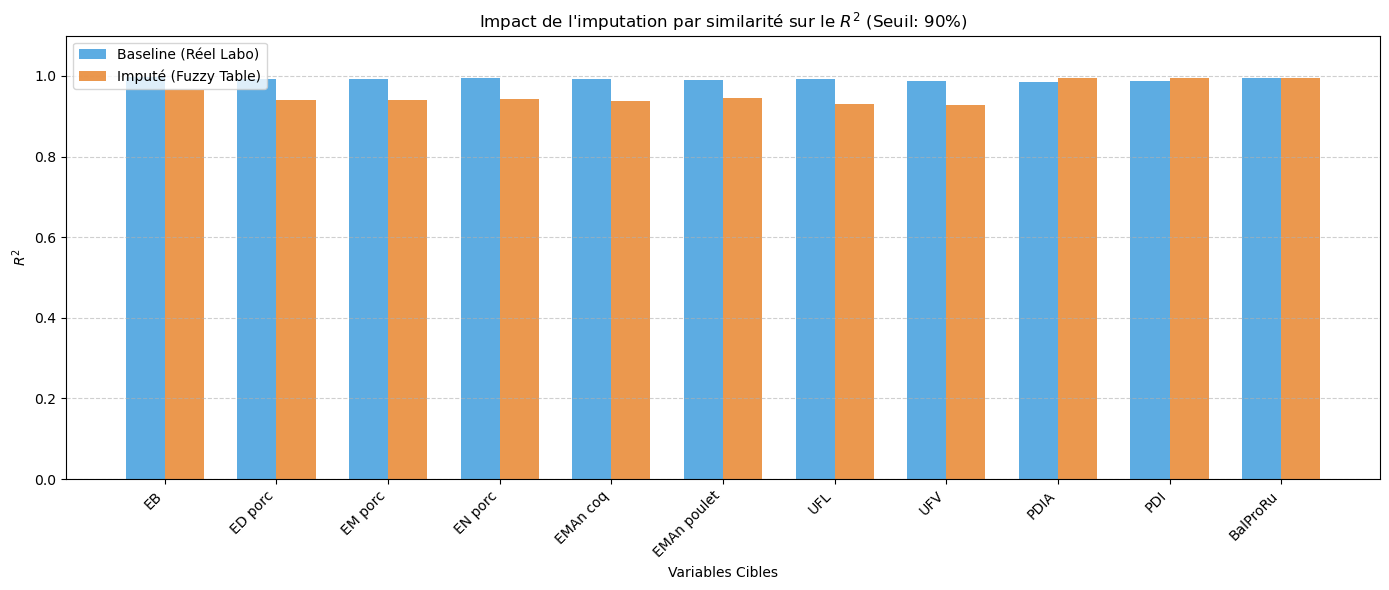

R² moyen Baseline : 0.9911
R² moyen Imputé : 0.9559
ΔR² moyen : -0.0352


In [73]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. On récupère les indices des lignes qui ont survécu au seuil de 90%
indices_test_filtres = X_test_imputed.index 

# 2. On synchronise les cibles réelles (y) sur ces indices
y_test_filtered = y_test.loc[indices_test_filtres]

results_comp = []

for target in vars_cibles:
    # 3. ON RECALCULE les prédictions sur le set filtré uniquement
    # Pour la table (Imputé)
    y_pred_imp = models_baseline[target].predict(X_test_imputed[vars_expl])
    
    # Pour le labo (Baseline - sur les mêmes lignes)
    y_pred_bl = models_baseline[target].predict(X_test.loc[indices_test_filtres, vars_expl])
    
    # 4. Calcul des scores (les longueurs sont maintenant identiques : 908)
    r2_bl = r2_score(y_test_filtered[target], y_pred_bl)
    r2_imp = r2_score(y_test_filtered[target], y_pred_imp)
    
    results_comp.append({
        'Variable': simplified_names.get(target, target),
        'R2 Baseline': round(r2_bl, 4),
        'R2 Imputé': round(r2_imp, 4),
        'ΔR2': round(r2_imp - r2_bl, 4)
    })

df_res = pd.DataFrame(results_comp)
print(f"Comparaison sur {len(indices_test_filtres)} échantillons (Seuil 90%)")
print(df_res.to_string(index=False))

# Affichage du tableau
print(f"COMPARAISON DES PERFORMANCES (N={len(y_test_filtered)} échantillons)")
print(df_res[['Variable', 'R2 Baseline', 'R2 Imputé', 'ΔR2']].to_string(index=False))

# Visualisation graphique
plt.figure(figsize=(14, 6))
x = np.arange(len(df_res))
width = 0.35

plt.bar(x - width/2, df_res['R2 Baseline'], width, label='Baseline (Réel Labo)', color='#3498db', alpha=0.8)
plt.bar(x + width/2, df_res['R2 Imputé'], width, label='Imputé (Fuzzy Table)', color='#e67e22', alpha=0.8)

plt.xlabel('Variables Cibles')
plt.ylabel('$R^2$')
plt.title(f"Impact de l'imputation par similarité sur le $R^2$ (Seuil: {SEUIL_CONFIANCE}%)")
plt.xticks(x, df_res['Variable'], rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Sauvegarde ou affichage
plt.savefig('comparaison_imputation_r2.png')
plt.show()

print(f"R² moyen Baseline : {df_res['R2 Baseline'].mean():.4f}")
print(f"R² moyen Imputé : {df_res['R2 Imputé'].mean():.4f}")
print(f"ΔR² moyen : {df_res['ΔR2'].mean():.4f}")